# **Task 0.2.2 Transfer Learning from MNIST**

• Prepare a CNN of your choice and train it on the MNIST data. Report the accuracy<br>
• Use the above model as a pre-trained CNN for the SVHN dataset. Report the accuracy<br>
• In the third step you are performing transfer learning from MNIST to SVHN (optional).<br>

## **Prepare a CNN of your choice and train it on the MNIST data.**

----Training on MNIST----
Epoch 01 | Train Loss: 0.4208 | Val Loss: 0.1132 | Val Acc: 96.71%
Epoch 02 | Train Loss: 0.0892 | Val Loss: 0.0790 | Val Acc: 97.74%
Epoch 03 | Train Loss: 0.0620 | Val Loss: 0.0588 | Val Acc: 98.24%
Epoch 04 | Train Loss: 0.0493 | Val Loss: 0.0512 | Val Acc: 98.50%
Epoch 05 | Train Loss: 0.0388 | Val Loss: 0.0500 | Val Acc: 98.46%
Epoch 06 | Train Loss: 0.0324 | Val Loss: 0.0428 | Val Acc: 98.79%
Epoch 07 | Train Loss: 0.0284 | Val Loss: 0.0414 | Val Acc: 98.84%
Epoch 08 | Train Loss: 0.0251 | Val Loss: 0.0398 | Val Acc: 98.79%
Epoch 09 | Train Loss: 0.0219 | Val Loss: 0.0388 | Val Acc: 98.90%
Epoch 10 | Train Loss: 0.0174 | Val Loss: 0.0496 | Val Acc: 98.53%
Epoch 11 | Train Loss: 0.0155 | Val Loss: 0.0439 | Val Acc: 98.72%
Epoch 12 | Train Loss: 0.0124 | Val Loss: 0.0405 | Val Acc: 98.77%
Epoch 13 | Train Loss: 0.0121 | Val Loss: 0.0382 | Val Acc: 99.03%
Epoch 14 | Train Loss: 0.0099 | Val Loss: 0.0482 | Val Acc: 98.79%
Epoch 15 | Train Loss: 0.0081 | Val 

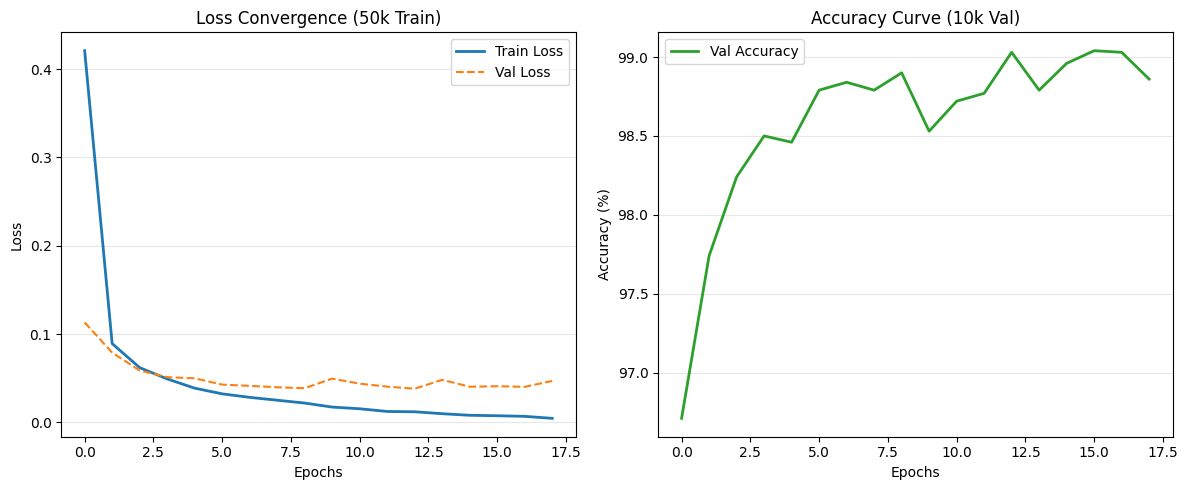

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset, ConcatDataset
import os

#  Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LR = 1e-4
MAX_EPOCHS = 50
MODEL_PATH = "mnist_pretrained.pth"

# Data
# Resized MNIST to 32x32 and convert to 3 channels to match SVHN architecture
transform_mnist = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

transform_svhn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Load MNIST
# Data Splitting
train_part = datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
test_part = datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)
full_dataset = ConcatDataset([train_part, test_part])

indices = list(range(len(full_dataset)))
np.random.seed(42)
np.random.shuffle(indices)

# Explicit numerical splits
train_idx = indices[:50000]
val_idx = indices[50000:60000]
test_idx = indices[60000:]

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=BATCH_SIZE, shuffle=False)

# --- Model ---
# Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(0.01),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.LeakyReLU(0.01),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Train on MNIST
print(f"----Training on MNIST----")
model = SimpleCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

# Training ---
best_val_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            v_loss = criterion(outputs, labels)
            running_val_loss += v_loss.item()
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100. * correct / total

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    # Save best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"--> Convergence reached at epoch {epoch+1}.")
        break

# Final Evaluation on Test Set
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, pred = outputs.max(1)
        test_total += labels.size(0)
        test_correct += pred.eq(labels).sum().item()

print(f"\nFinal Test Accuracy: {100. * test_correct / test_total:.2f}%")
# Save the trained weights

# --- 5. Visualization ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='#ff7f0e', linestyle='--')
plt.title('Loss Convergence (50k Train)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='#2ca02c', linewidth=2)
plt.title('Accuracy Curve (10k Val)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## **Use the above model as a pre-trained CNN for the SVHN dataset.**

In [4]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset

# SVHN Data Preparation
transform_svhn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

svhn_test_dataset = datasets.SVHN(root='./data', split='test', download=True, transform=transform_svhn)

svhn_test_loader = DataLoader(Subset(svhn_test_dataset, range(10000)), batch_size=64, shuffle=False)

# Load the Pre-trained MNIST Model
model = SimpleCNN().to(DEVICE)
model.load_state_dict(torch.load("mnist_pretrained.pth"))
model.eval()

print("\n--Evaluating MNIST Pre-trained Model on SVHN--")
correct = 0
total = 0

with torch.no_grad():
    for images, labels in svhn_test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)

        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

final_accuracy = 100. * correct / total
print(f"Final Accuracy of MNIST-trained model on SVHN: {final_accuracy:.2f}%")


--Evaluating MNIST Pre-trained Model on SVHN--
Final Accuracy of MNIST-trained model on SVHN: 37.45%


## **Performing transfer learning from MNIST to SVHN**


---- Fine-Tuning on SVHN ----
Epoch 01 | Train Loss: 1.6013 | Val Loss: 1.3664 | Val Acc: 57.56%
Epoch 02 | Train Loss: 1.2240 | Val Loss: 1.1249 | Val Acc: 65.71%
Epoch 03 | Train Loss: 1.0389 | Val Loss: 0.9892 | Val Acc: 70.56%
Epoch 04 | Train Loss: 0.9229 | Val Loss: 0.8967 | Val Acc: 73.81%
Epoch 05 | Train Loss: 0.8428 | Val Loss: 0.8347 | Val Acc: 75.68%
Epoch 06 | Train Loss: 0.7850 | Val Loss: 0.7878 | Val Acc: 77.24%
Epoch 07 | Train Loss: 0.7413 | Val Loss: 0.7518 | Val Acc: 78.31%
Epoch 08 | Train Loss: 0.7063 | Val Loss: 0.7246 | Val Acc: 79.57%
Epoch 09 | Train Loss: 0.6777 | Val Loss: 0.7000 | Val Acc: 80.03%
Epoch 10 | Train Loss: 0.6536 | Val Loss: 0.6810 | Val Acc: 80.86%
Epoch 11 | Train Loss: 0.6326 | Val Loss: 0.6641 | Val Acc: 81.13%
Epoch 12 | Train Loss: 0.6137 | Val Loss: 0.6494 | Val Acc: 81.86%
Epoch 13 | Train Loss: 0.5964 | Val Loss: 0.6322 | Val Acc: 82.46%
Epoch 14 | Train Loss: 0.5838 | Val Loss: 0.6243 | Val Acc: 82.68%
Epoch 15 | Train Loss: 0.5670 |

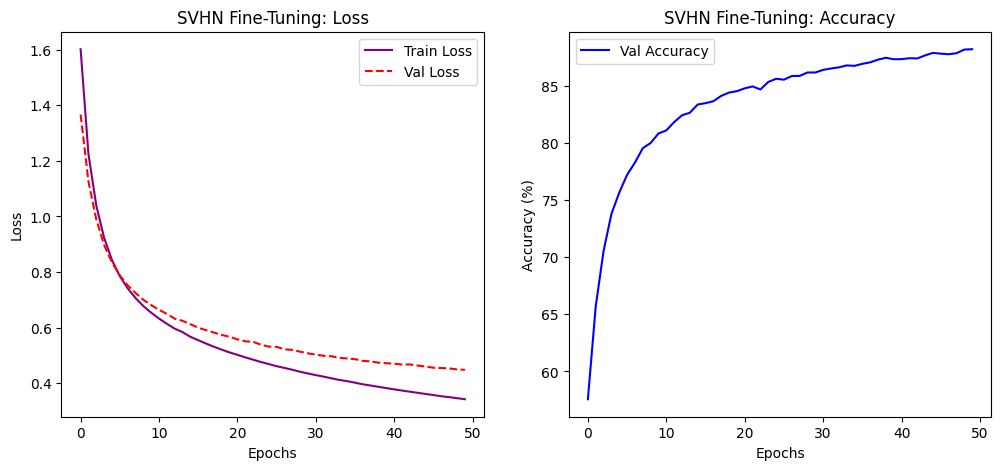

In [5]:
# SVHN Data Preparation
transform_svhn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

svhn_train_part = datasets.SVHN(root='./data', split='train', download=True, transform=transform_svhn)
svhn_test_part = datasets.SVHN(root='./data', split='test', download=True, transform=transform_svhn)
svhn_full = ConcatDataset([svhn_train_part, svhn_test_part])

svhn_indices = list(range(len(svhn_full)))
np.random.seed(42)
np.random.shuffle(svhn_indices)

svhn_train_idx = svhn_indices[:50000]
svhn_val_idx   = svhn_indices[50000:60000]
svhn_test_idx  = svhn_indices[60000:70000]

svhn_train_loader = DataLoader(Subset(svhn_full, svhn_train_idx), batch_size=BATCH_SIZE, shuffle=True)
svhn_val_loader   = DataLoader(Subset(svhn_full, svhn_val_idx), batch_size=BATCH_SIZE, shuffle=False)
svhn_test_loader  = DataLoader(Subset(svhn_full, svhn_test_idx), batch_size=BATCH_SIZE, shuffle=False)

# Load Pre-trained MNIST Model
tl_model = SimpleCNN().to(DEVICE)
tl_model.load_state_dict(torch.load("mnist_pretrained.pth"))

optimizer = optim.Adam(tl_model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

tl_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

# Fine-Tuning Loop
print("\n---- Fine-Tuning on SVHN ----")
best_tl_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    tl_model.train()
    running_train_loss = 0.0
    for images, labels in svhn_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(tl_model(images), labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(svhn_train_loader)

    # Validation check
    tl_model.eval()
    running_val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in svhn_val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = tl_model(images)
            v_loss = criterion(outputs, labels)
            running_val_loss += v_loss.item()
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(svhn_val_loader)
    epoch_val_acc = 100. * correct / total

    tl_history['train_loss'].append(epoch_train_loss)
    tl_history['val_loss'].append(epoch_val_loss)
    tl_history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    # Convergence Check
    if epoch_val_loss < best_tl_loss:
        best_tl_loss = epoch_val_loss
        torch.save(tl_model.state_dict(), "svhn_finetuned.pth")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        #print(f"SVHN Fine-Tuning Converged at epoch {epoch+1}.")
        break

# Final Evaluation on Test Images
tl_model.load_state_dict(torch.load("svhn_finetuned.pth"))
tl_model.eval()
final_correct, final_total = 0, 0
with torch.no_grad():
    for images, labels in svhn_test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = tl_model(images)
        _, pred = outputs.max(1)
        final_total += labels.size(0)
        final_correct += pred.eq(labels).sum().item()

print(f"\nFinal Test Accuracy after Transfer Learning: {100. * final_correct / final_total:.2f}%")

#  Plotting SVHN Convergence
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tl_history['train_loss'], label='Train Loss', color='purple')
plt.plot(tl_history['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('SVHN Fine-Tuning: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(tl_history['val_acc'], label='Val Accuracy', color='blue')
plt.title('SVHN Fine-Tuning: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()